# Fusion multimodale — Image + Texte

## Description du projet

Ce notebook implémente une **fusion multimodale** combinant les représentations image (EfficientNetB0) et texte (Bi-LSTM) pour améliorer la classification multi-label.

L'hypothèse est que les deux modalités sont **complémentaires** : l'image capture les aspects visuels, le texte contextualise et précise.

**Deux stratégies de fusion :**
1. **Early Fusion (feature-level)** : concaténer les embeddings image et texte extraits des modèles unimodaux → classifier commun
2. **Joint Fusion (end-to-end)** : architecture unifiée qui apprend conjointement les représentations des deux modalités

---

**Structure :**
1. Configuration et chargement des données
2. Extraction des features unimodales
3. Fusion 1 — Early Fusion (features préextrait + classifieur)
4. Fusion 2 — Joint Fusion (architecture end-to-end)
5. Comparaison complète (unimodaux + multimodaux)
6. Analyse et interprétation

## 1. Configuration et chargement

In [1]:
import os
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score, precision_score, recall_score

plt.rcParams['figure.dpi'] = 100
np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")

# ── Chemins ──────────────────────────────────────────────────────────────────
# Structure du dataset extrait :
#   data/multimodal/COMP5329S1A2Dataset/data/*.jpg   → images (0.jpg, 1.jpg, ...)
#   data/multimodal/COMP5329S1A2Dataset/train.csv    → annotations
DATASET_DIR = '../data/multimodal/COMP5329S1A2Dataset/'
DATA_DIR    = '../data/multimodal/'                  # dossier pour les artefacts générés
IMG_DIR     = os.path.join(DATASET_DIR, 'data/')    # images/*.jpg
TRAIN_CSV   = os.path.join(DATASET_DIR, 'train.csv')

# Constantes
IMG_SIZE   = 224
N_CLASSES  = 18
ALL_LABELS = [l for l in range(1, 20) if l != 12]
THRESHOLD  = 0.5
MAX_LEN    = 20
EMBED_DIM  = 128

print("Répertoire images :", os.path.abspath(IMG_DIR))
print("train.csv existe  :", os.path.exists(TRAIN_CSV))


Device : cpu
Répertoire images : c:\Users\DELL\Desktop\ESTIA\COURS\MLOps\Projet_final\data\multimodal\COMP5329S1A2Dataset\data
train.csv existe  : True


In [2]:
# ── Chargement des données (même split que EDA) ───────────────────────────────
# on_bad_lines='skip' : certaines captions contiennent des virgules → lignes mal formées
df = pd.read_csv(TRAIN_CSV, on_bad_lines='skip')

def parse_labels(s):
    return [int(x) for x in str(s).split()] if pd.notna(s) else []

df['labels_list'] = df['Labels'].apply(parse_labels)

idx_train = pd.read_csv('../data/multimodal/idx_train.csv', header=None)[0].tolist()
idx_val   = pd.read_csv('../data/multimodal/idx_val.csv',   header=None)[0].tolist()
idx_test  = pd.read_csv('../data/multimodal/idx_test.csv',  header=None)[0].tolist()

df_train = df.loc[idx_train].reset_index(drop=True)
df_val   = df.loc[idx_val].reset_index(drop=True)
df_test  = df.loc[idx_test].reset_index(drop=True)

mlb = pickle.load(open('../data/multimodal/mlb.pkl', 'rb'))
y_train = mlb.transform(df_train['labels_list']).astype(np.float32)
y_val   = mlb.transform(df_val['labels_list']).astype(np.float32)
y_test  = mlb.transform(df_test['labels_list']).astype(np.float32)

# Charger les artefacts texte (vocabulaire, tokeniseur)
text_artifacts = pickle.load(open('../data/multimodal/text_artifacts.pkl', 'rb'))
word2idx   = text_artifacts['word2idx']
VOCAB_SIZE = text_artifacts['vocab_size']

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")


Train: 20997 | Val: 4499 | Test: 4500


In [3]:
# ── Prétraitement texte (même que classification_textes.ipynb) ────────────────
STOPWORDS = {'a', 'an', 'the', 'in', 'on', 'at', 'is', 'are', 'of', 'and',
             'with', 'to', 'for', 'as', 'by', 'that', 'this', 'it', 'its',
             'from', 'has', 'have', 'be', 'been', 'being', 'was', 'were',
             'he', 'she', 'they', 'their', 'some', 'two', 'three', 'one', 'into'}

def preprocess_text(text):
    text   = re.sub(r'[^a-z\s]', '', str(text).lower())
    tokens = [w for w in text.split() if w not in STOPWORDS and len(w) > 1]
    return ' '.join(tokens)

def encode_caption(caption, word2idx, max_len=MAX_LEN):
    tokens = preprocess_text(caption).split()[:max_len]
    ids    = [word2idx.get(t, 1) for t in tokens]  # 1 = <UNK>
    ids   += [0] * (max_len - len(ids))             # 0 = <PAD>
    return ids

# Transformations images
img_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

print("✓ Prétraitement configuré")

✓ Prétraitement configuré


## 2. Extraction des features unimodales

In [4]:
# ── Chargement des modèles unimodaux entraînés ────────────────────────────────

# Modèle image (EfficientNetB0 Fine-tuned)
img_backbone = models.efficientnet_b0(weights='IMAGENET1K_V1')
in_features  = img_backbone.classifier[1].in_features
img_backbone.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, N_CLASSES),
)
img_backbone.load_state_dict(
    torch.load('../model/image_model_final.pth', map_location=DEVICE)
)
img_backbone = img_backbone.to(DEVICE)

# Modèle texte (Bi-LSTM)
class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_classes, n_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers,
                                 bidirectional=True, batch_first=True, dropout=dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, n_classes),
        )
    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.lstm(emb)
        return self.classifier(out.mean(dim=1))

text_model = BiLSTM(VOCAB_SIZE, EMBED_DIM, 128, N_CLASSES).to(DEVICE)
text_model.load_state_dict(
    torch.load('../model/text_model_final.pth', map_location=DEVICE)
)

print("✓ Modèles unimodaux chargés")

✓ Modèles unimodaux chargés


In [5]:
# ── Extracteurs de features (sans la tête de classification) ──────────────────

class ImageFeatureExtractor(nn.Module):
    """Extrait les embeddings 1280-dim d'EfficientNetB0 (avant le classifier)."""
    def __init__(self, backbone):
        super().__init__()
        self.features = backbone.features
        self.pool     = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        x = self.features(x)      # (B, 1280, H', W')
        x = self.pool(x)          # (B, 1280, 1, 1)
        return x.flatten(1)       # (B, 1280)


class TextFeatureExtractor(nn.Module):
    """Extrait les embeddings 256-dim du Bi-LSTM (avant le classifier)."""
    def __init__(self, text_model):
        super().__init__()
        self.embedding = text_model.embedding
        self.lstm      = text_model.lstm

    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.lstm(emb)
        return out.mean(dim=1)    # (B, hidden*2) = (B, 256)


img_extractor  = ImageFeatureExtractor(img_backbone).to(DEVICE)
text_extractor = TextFeatureExtractor(text_model).to(DEVICE)

IMG_FEAT_DIM  = 1280   # sortie EfficientNetB0
TEXT_FEAT_DIM = 256    # sortie Bi-LSTM bidirectionnel (128 × 2)
print(f"Dim features image : {IMG_FEAT_DIM} | texte : {TEXT_FEAT_DIM}")

Dim features image : 1280 | texte : 256


In [6]:
# ── Dataset multimodal ────────────────────────────────────────────────────────
class MultimodalDataset(Dataset):
    """Dataset combinant image et texte pour la fusion multimodale."""
    def __init__(self, df, labels, img_dir, word2idx, transform=None, max_len=MAX_LEN):
        self.df        = df.reset_index(drop=True)
        self.labels    = torch.tensor(labels, dtype=torch.float32)
        self.img_dir   = img_dir
        self.word2idx  = word2idx
        self.transform = transform
        self.max_len   = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Image
        img = Image.open(os.path.join(self.img_dir, row['ImageID'])).convert('RGB')
        if self.transform:
            img = self.transform(img)

        # Texte
        text = torch.tensor(encode_caption(row['Caption'], self.word2idx, self.max_len), dtype=torch.long)

        return img, text, self.labels[idx]


BATCH = 32
train_mm_ds = MultimodalDataset(df_train, y_train, IMG_DIR, word2idx, train_transform)
val_mm_ds   = MultimodalDataset(df_val,   y_val,   IMG_DIR, word2idx, img_transform)
test_mm_ds  = MultimodalDataset(df_test,  y_test,  IMG_DIR, word2idx, img_transform)

train_mm = DataLoader(train_mm_ds, batch_size=BATCH, shuffle=True,  num_workers=0)
val_mm   = DataLoader(val_mm_ds,   batch_size=BATCH, shuffle=False, num_workers=0)
test_mm  = DataLoader(test_mm_ds,  batch_size=BATCH, shuffle=False, num_workers=0)

print(f"Batches/epoch — Train: {len(train_mm)} | Val: {len(val_mm)}")

Batches/epoch — Train: 657 | Val: 141


## 3. Fusion 1 — Early Fusion (feature-level)

In [7]:
# ── Early Fusion : concaténer les features et entraîner un classifieur ────────
#
# Principe :
#   1. Extraire les features image (1280-dim) avec l'extracteur gelé
#   2. Extraire les features texte (256-dim) avec l'extracteur gelé
#   3. Concaténer → vecteur 1536-dim
#   4. Entraîner un MLP de classification
#
# Avantages : simple, rapide à entraîner, exploite les features pré-apprises
# Inconvénients : pas d'interaction apprise entre modalités

class EarlyFusionClassifier(nn.Module):
    """
    Early Fusion : features image + texte concaténées → MLP.
    Les extracteurs sont gelés, seule la tête est entraînée.
    """
    def __init__(self, img_extractor, text_extractor, img_dim, text_dim, n_classes):
        super().__init__()
        self.img_extractor  = img_extractor
        self.text_extractor = text_extractor

        # Projections pour normaliser les features de chaque modalité
        self.img_proj  = nn.Sequential(nn.Linear(img_dim, 256), nn.ReLU(), nn.Dropout(0.3))
        self.text_proj = nn.Sequential(nn.Linear(text_dim, 256), nn.ReLU(), nn.Dropout(0.3))

        # Classifieur sur la concaténation
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, n_classes),
        )

    def forward(self, img, text):
        # Extraction avec gradients stoppés (extracteurs gelés)
        with torch.no_grad():
            img_feat  = self.img_extractor(img)    # (B, 1280)
            text_feat = self.text_extractor(text)  # (B, 256)

        # Projection + concaténation
        img_proj  = self.img_proj(img_feat)        # (B, 256)
        text_proj = self.text_proj(text_feat)      # (B, 256)
        fused     = torch.cat([img_proj, text_proj], dim=1)  # (B, 512)

        return self.classifier(fused)              # (B, n_classes)


early_fusion = EarlyFusionClassifier(
    img_extractor, text_extractor, IMG_FEAT_DIM, TEXT_FEAT_DIM, N_CLASSES
).to(DEVICE)

trainable = sum(p.numel() for p in early_fusion.parameters() if p.requires_grad)
print(f"Early Fusion — Paramètres entraînables : {trainable:,}")

Early Fusion — Paramètres entraînables : 5,962,510


In [8]:
def train_multimodal(model, train_loader, val_loader, epochs, lr, device, model_name, y_ref):
    """Entraînement pour modèles multimodaux (image + texte)."""
    pos = y_ref.sum(axis=0)
    neg = len(y_ref) - pos
    pos_weight = torch.tensor(neg / (pos + 1e-6), dtype=torch.float32).to(device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    best_f1, patience_cnt = 0, 0
    PATIENCE = 5

    for epoch in range(epochs):
        model.train()
        t_losses, t_preds, t_labs = [], [], []
        for imgs, texts, labs in train_loader:
            imgs, texts, labs = imgs.to(device), texts.to(device), labs.to(device)
            optimizer.zero_grad()
            logits = model(imgs, texts)
            loss   = criterion(logits, labs)
            loss.backward()
            optimizer.step()
            t_losses.append(loss.item())
            t_preds.append(torch.sigmoid(logits).detach().cpu().numpy())
            t_labs.append(labs.cpu().numpy())

        model.eval()
        v_losses, v_preds, v_labs = [], [], []
        with torch.no_grad():
            for imgs, texts, labs in val_loader:
                imgs, texts, labs = imgs.to(device), texts.to(device), labs.to(device)
                logits = model(imgs, texts)
                v_losses.append(criterion(logits, labs).item())
                v_preds.append(torch.sigmoid(logits).cpu().numpy())
                v_labs.append(labs.cpu().numpy())

        yt_tr = np.vstack(t_labs);  yp_tr = (np.vstack(t_preds) >= THRESHOLD).astype(int)
        yt_v  = np.vstack(v_labs);  yp_v  = (np.vstack(v_preds) >= THRESHOLD).astype(int)

        tl = np.mean(t_losses); vl = np.mean(v_losses)
        tf = f1_score(yt_tr, yp_tr, average='micro', zero_division=0)
        vf = f1_score(yt_v,  yp_v,  average='micro', zero_division=0)

        history['train_loss'].append(tl); history['val_loss'].append(vl)
        history['train_f1'].append(tf);  history['val_f1'].append(vf)
        scheduler.step(vl)
        print(f"Epoch {epoch+1:3d}/{epochs} | loss={tl:.4f}/{vl:.4f} | F1={tf:.4f}/{vf:.4f}")

        if vf > best_f1:
            best_f1 = vf
            torch.save(model.state_dict(), f'../model/{model_name}_best.pth')
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f"  → Early stopping epoch {epoch+1}")
                break

    model.load_state_dict(torch.load(f'../model/{model_name}_best.pth', map_location=device))
    return history


def eval_multimodal(model, loader, device):
    model.eval()
    preds, labs = [], []
    with torch.no_grad():
        for imgs, texts, labels in loader:
            logits = model(imgs.to(device), texts.to(device))
            preds.append(torch.sigmoid(logits).cpu().numpy())
            labs.append(labels.numpy())
    yp = np.vstack(preds)
    yt = np.vstack(labs)
    return yt, (yp >= THRESHOLD).astype(int), yp

=== Entraînement Early Fusion ===
Epoch   1/20 | loss=0.2321/1.3379 | F1=0.7063/0.6906
Epoch   2/20 | loss=0.1662/1.7926 | F1=0.7658/0.7093
Epoch   3/20 | loss=0.1515/1.7435 | F1=0.7779/0.7252
Epoch   4/20 | loss=0.1459/1.8445 | F1=0.7845/0.7159
Epoch   5/20 | loss=0.1426/2.0280 | F1=0.7871/0.7236
Epoch   6/20 | loss=0.1307/2.0945 | F1=0.8001/0.7235
Epoch   7/20 | loss=0.1208/2.3022 | F1=0.8085/0.7295
Epoch   8/20 | loss=0.1192/2.3742 | F1=0.8091/0.7428
Epoch   9/20 | loss=0.1194/2.3034 | F1=0.8142/0.7275
Epoch  10/20 | loss=0.1104/2.4738 | F1=0.8192/0.7360
Epoch  11/20 | loss=0.1056/2.4534 | F1=0.8223/0.7281
Epoch  12/20 | loss=0.1064/2.5866 | F1=0.8236/0.7409
Epoch  13/20 | loss=0.1029/2.6757 | F1=0.8252/0.7291
  → Early stopping epoch 13


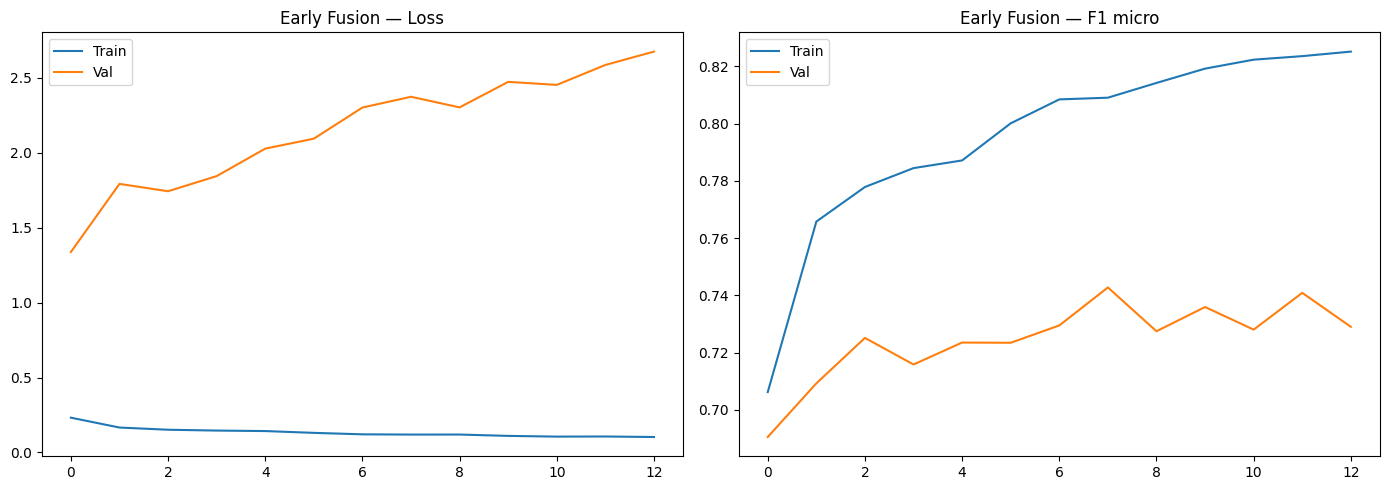

Early Fusion Test: {'f1_micro': 0.7383227176220807, 'f1_macro': 0.6664807591027889, 'precision': 0.6924704418170504, 'recall': 0.7906778456728719}


In [9]:
print("=== Entraînement Early Fusion ===")
hist_ef = train_multimodal(
    early_fusion, train_mm, val_mm,
    epochs=20, lr=1e-3, device=DEVICE, model_name='early_fusion', y_ref=y_train
)

# Courbes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(hist_ef['train_loss'], label='Train'); axes[0].plot(hist_ef['val_loss'], label='Val')
axes[0].set_title('Early Fusion — Loss'); axes[0].legend()
axes[1].plot(hist_ef['train_f1'], label='Train'); axes[1].plot(hist_ef['val_f1'], label='Val')
axes[1].set_title('Early Fusion — F1 micro'); axes[1].legend()
plt.tight_layout()
plt.savefig('../monitoring/output/fusion_early_curves.png', bbox_inches='tight')
plt.show()

y_true_ef, y_pred_ef, _ = eval_multimodal(early_fusion, test_mm, DEVICE)
metrics_ef = {
    'f1_micro':  f1_score(y_true_ef, y_pred_ef, average='micro', zero_division=0),
    'f1_macro':  f1_score(y_true_ef, y_pred_ef, average='macro', zero_division=0),
    'precision': precision_score(y_true_ef, y_pred_ef, average='micro', zero_division=0),
    'recall':    recall_score(y_true_ef, y_pred_ef, average='micro', zero_division=0),
}
print("Early Fusion Test:", metrics_ef)

## 4. Fusion 2 — Joint Fusion (end-to-end)

In [10]:
# ── Joint Fusion : apprentissage end-to-end des deux modalités ────────────────
#
# Principe :
#   1. Backbone image (EfficientNetB0) partiellement dégelé → features image
#   2. Bi-LSTM → features texte
#   3. Mécanisme d'attention croisée simple entre les deux modalités
#   4. Classifier sur la représentation fusionnée
#
# Avantages : les deux modalités s'adaptent conjointement à la tâche
# Inconvénients : plus lourd à entraîner, risque de surapprentissage

class JointFusionModel(nn.Module):
    """
    Joint Fusion end-to-end avec attention croisée.

    Architecture :
      - Branche image  : EfficientNetB0 (3 derniers blocs dégeleés) → proj 256-dim
      - Branche texte  : Bi-LSTM (entraîné) → proj 256-dim
      - Fusion         : concaténation + gate attention (pondération apprise)
      - Classifieur    : FC → sortie multi-label
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_classes,
                 img_feat_dim=1280, fused_dim=256):
        super().__init__()

        # ── Branche image ─────────────────────────────────────────────────────
        efficientnet = models.efficientnet_b0(weights='IMAGENET1K_V1')
        # Geler tout sauf les 3 derniers blocs
        for param in efficientnet.parameters():
            param.requires_grad = False
        for block in list(efficientnet.features.children())[-3:]:
            for param in block.parameters():
                param.requires_grad = True
        self.img_features = efficientnet.features
        self.img_pool     = nn.AdaptiveAvgPool2d(1)
        self.img_proj     = nn.Sequential(
            nn.Linear(img_feat_dim, fused_dim), nn.LayerNorm(fused_dim), nn.ReLU()
        )

        # ── Branche texte ─────────────────────────────────────────────────────
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, num_layers=2,
                                 bidirectional=True, batch_first=True, dropout=0.3)
        self.text_proj = nn.Sequential(
            nn.Linear(hidden_dim * 2, fused_dim), nn.LayerNorm(fused_dim), nn.ReLU()
        )

        # ── Fusion : gate attention ───────────────────────────────────────────
        # Apprend à pondérer l'importance relative de chaque modalité
        self.gate = nn.Sequential(
            nn.Linear(fused_dim * 2, 2),
            nn.Softmax(dim=-1)
        )

        # ── Classifieur ───────────────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, n_classes),
        )

    def forward(self, img, text):
        # Features image
        img_feat = self.img_features(img)
        img_feat = self.img_pool(img_feat).flatten(1)  # (B, 1280)
        img_proj = self.img_proj(img_feat)              # (B, 256)

        # Features texte
        emb = self.embedding(text)
        out, _ = self.lstm(emb)
        text_feat = out.mean(dim=1)                    # (B, hidden*2)
        text_proj = self.text_proj(text_feat)           # (B, 256)

        # Gate attention : pondération des deux modalités
        concat  = torch.cat([img_proj, text_proj], dim=1)  # (B, 512)
        weights = self.gate(concat)                         # (B, 2)

        # Fusion pondérée
        fused = weights[:, 0:1] * img_proj + weights[:, 1:2] * text_proj  # (B, 256)

        return self.classifier(fused)


joint_fusion = JointFusionModel(
    vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_dim=128,
    n_classes=N_CLASSES, fused_dim=256
).to(DEVICE)

trainable = sum(p.numel() for p in joint_fusion.parameters() if p.requires_grad)
total     = sum(p.numel() for p in joint_fusion.parameters())
print(f"Joint Fusion — Paramètres entraînables : {trainable:,} / {total:,}")

Joint Fusion — Paramètres entraînables : 5,012,016 / 5,863,824


=== Entraînement Joint Fusion ===
Epoch   1/20 | loss=0.8047/0.6282 | F1=0.3760/0.4387
Epoch   2/20 | loss=0.6413/0.5870 | F1=0.4623/0.4910
Epoch   3/20 | loss=0.5889/0.5848 | F1=0.4903/0.4979
Epoch   4/20 | loss=0.5314/0.5723 | F1=0.5186/0.5125
Epoch   5/20 | loss=0.5072/0.6076 | F1=0.5266/0.5581
Epoch   6/20 | loss=0.4733/0.6257 | F1=0.5429/0.5135
Epoch   7/20 | loss=0.4570/0.6248 | F1=0.5501/0.5819
Epoch   8/20 | loss=0.4290/0.6406 | F1=0.5673/0.5759
Epoch   9/20 | loss=0.3677/0.6156 | F1=0.6045/0.5618
Epoch  10/20 | loss=0.3311/0.7296 | F1=0.6277/0.6101
Epoch  11/20 | loss=0.3081/0.7536 | F1=0.6456/0.6139
Epoch  12/20 | loss=0.2950/0.7993 | F1=0.6560/0.6290
Epoch  13/20 | loss=0.2616/0.7846 | F1=0.6791/0.6311
Epoch  14/20 | loss=0.2415/0.8068 | F1=0.6961/0.6259
Epoch  15/20 | loss=0.2315/0.8842 | F1=0.7062/0.6529
Epoch  16/20 | loss=0.2300/0.9479 | F1=0.7084/0.6655
Epoch  17/20 | loss=0.2186/0.9434 | F1=0.7200/0.6624
Epoch  18/20 | loss=0.2045/0.9802 | F1=0.7278/0.6709
Epoch  19/20

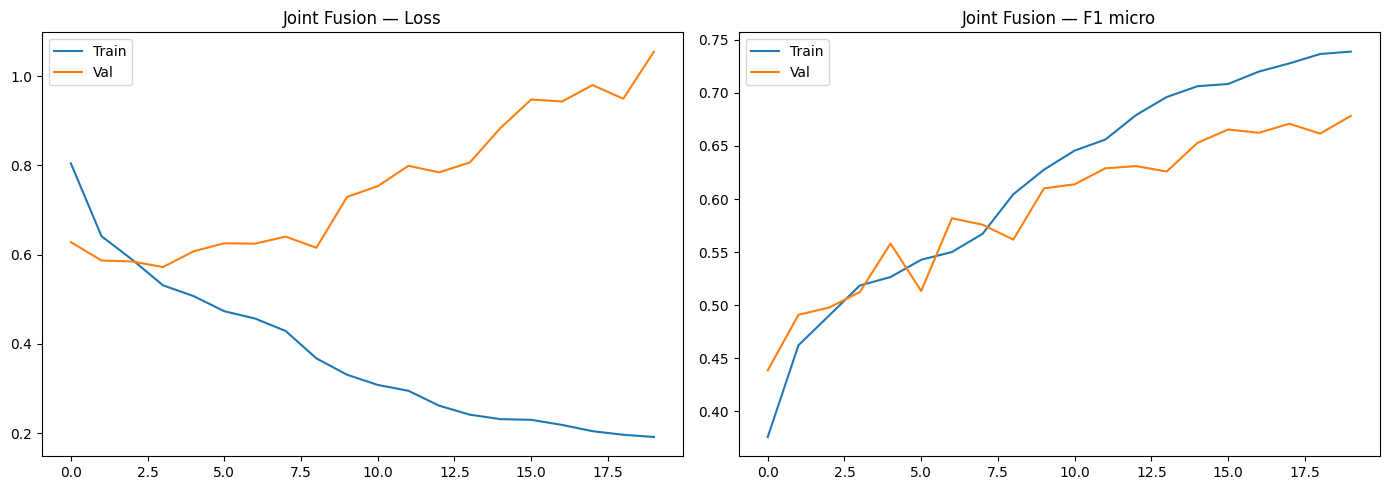

Joint Fusion Test: {'f1_micro': 0.6760936277754378, 'f1_macro': 0.5760324484099283, 'precision': 0.5863076601962012, 'recall': 0.7983515702714225}


In [11]:
print("=== Entraînement Joint Fusion ===")
hist_jf = train_multimodal(
    joint_fusion, train_mm, val_mm,
    epochs=20, lr=5e-4, device=DEVICE, model_name='joint_fusion', y_ref=y_train
)

# Courbes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(hist_jf['train_loss'], label='Train'); axes[0].plot(hist_jf['val_loss'], label='Val')
axes[0].set_title('Joint Fusion — Loss'); axes[0].legend()
axes[1].plot(hist_jf['train_f1'], label='Train'); axes[1].plot(hist_jf['val_f1'], label='Val')
axes[1].set_title('Joint Fusion — F1 micro'); axes[1].legend()
plt.tight_layout()
plt.savefig('../monitoring/output/fusion_joint_curves.png', bbox_inches='tight')
plt.show()

y_true_jf, y_pred_jf, _ = eval_multimodal(joint_fusion, test_mm, DEVICE)
metrics_jf = {
    'f1_micro':  f1_score(y_true_jf, y_pred_jf, average='micro', zero_division=0),
    'f1_macro':  f1_score(y_true_jf, y_pred_jf, average='macro', zero_division=0),
    'precision': precision_score(y_true_jf, y_pred_jf, average='micro', zero_division=0),
    'recall':    recall_score(y_true_jf, y_pred_jf, average='micro', zero_division=0),
}
print("Joint Fusion Test:", metrics_jf)

## 5. Comparaison complète — Unimodaux vs Multimodaux

In [12]:
# Récupérer les métriques unimodales depuis les notebooks précédents
# (recharger les modèles et évaluer sur le même jeu de test)

# Image seule — EfficientNetB0 FT
from torch.utils.data import Dataset as TDataset

class ImageOnlyDataset(TDataset):
    def __init__(self, df, labels, img_dir, transform):
        self.df = df.reset_index(drop=True)
        self.labels = torch.tensor(labels, dtype=torch.float32)
        self.img_dir = img_dir
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        img = Image.open(os.path.join(self.img_dir, self.df.iloc[i]['ImageID'])).convert('RGB')
        return self.transform(img), self.labels[i]

test_img_ds   = ImageOnlyDataset(df_test, y_test, IMG_DIR, img_transform)
test_img_loader = DataLoader(test_img_ds, batch_size=32, shuffle=False)

img_backbone.eval()
preds_img, labs_img = [], []
with torch.no_grad():
    for imgs, labs in test_img_loader:
        logits = img_backbone(imgs.to(DEVICE))
        preds_img.append(torch.sigmoid(logits).cpu().numpy())
        labs_img.append(labs.numpy())
y_true_img = np.vstack(labs_img)
y_pred_img = (np.vstack(preds_img) >= THRESHOLD).astype(int)
metrics_img = {
    'f1_micro':  f1_score(y_true_img, y_pred_img, average='micro', zero_division=0),
    'f1_macro':  f1_score(y_true_img, y_pred_img, average='macro', zero_division=0),
    'precision': precision_score(y_true_img, y_pred_img, average='micro', zero_division=0),
    'recall':    recall_score(y_true_img, y_pred_img, average='micro', zero_division=0),
}
print("Image seule :", metrics_img)

Image seule : {'f1_micro': 0.6530518586507572, 'f1_macro': 0.5460740167553818, 'precision': 0.5475709475709476, 'recall': 0.8088674150916584}


In [13]:
# Texte seul — Bi-LSTM
class TextOnlyDataset(TDataset):
    def __init__(self, df, labels, word2idx, max_len):
        self.X = torch.tensor(
            [encode_caption(c, word2idx, max_len) for c in df['Caption'].fillna('')], dtype=torch.long
        )
        self.y = torch.tensor(labels, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

test_text_ds     = TextOnlyDataset(df_test, y_test, word2idx, MAX_LEN)
test_text_loader = DataLoader(test_text_ds, batch_size=64, shuffle=False)

text_model.eval()
preds_txt, labs_txt = [], []
with torch.no_grad():
    for seqs, labs in test_text_loader:
        logits = text_model(seqs.to(DEVICE))
        preds_txt.append(torch.sigmoid(logits).cpu().numpy())
        labs_txt.append(labs.numpy())
y_true_txt = np.vstack(labs_txt)
y_pred_txt = (np.vstack(preds_txt) >= THRESHOLD).astype(int)
metrics_txt = {
    'f1_micro':  f1_score(y_true_txt, y_pred_txt, average='micro', zero_division=0),
    'f1_macro':  f1_score(y_true_txt, y_pred_txt, average='macro', zero_division=0),
    'precision': precision_score(y_true_txt, y_pred_txt, average='micro', zero_division=0),
    'recall':    recall_score(y_true_txt, y_pred_txt, average='micro', zero_division=0),
}
print("Texte seul :", metrics_txt)

Texte seul : {'f1_micro': 0.6574760111745415, 'f1_macro': 0.5926033220419016, 'precision': 0.5740799660621487, 'recall': 0.7692198379991474}


In [14]:
# ── Tableau de synthèse ───────────────────────────────────────────────────────
final_comparison = pd.DataFrame([
    {'Modèle': 'Image seule (EfficientNetB0 FT)',  **metrics_img},
    {'Modèle': 'Texte seul (Bi-LSTM)',             **metrics_txt},
    {'Modèle': 'Early Fusion (concaténation)',     **metrics_ef},
    {'Modèle': 'Joint Fusion (end-to-end)',        **metrics_jf},
])

print("=" * 75)
print(final_comparison.to_string(index=False, float_format='{:.4f}'.format))
print("=" * 75)

                         Modèle  f1_micro  f1_macro  precision  recall
Image seule (EfficientNetB0 FT)    0.6531    0.5461     0.5476  0.8089
           Texte seul (Bi-LSTM)    0.6575    0.5926     0.5741  0.7692
   Early Fusion (concaténation)    0.7383    0.6665     0.6925  0.7907
      Joint Fusion (end-to-end)    0.6761    0.5760     0.5863  0.7984


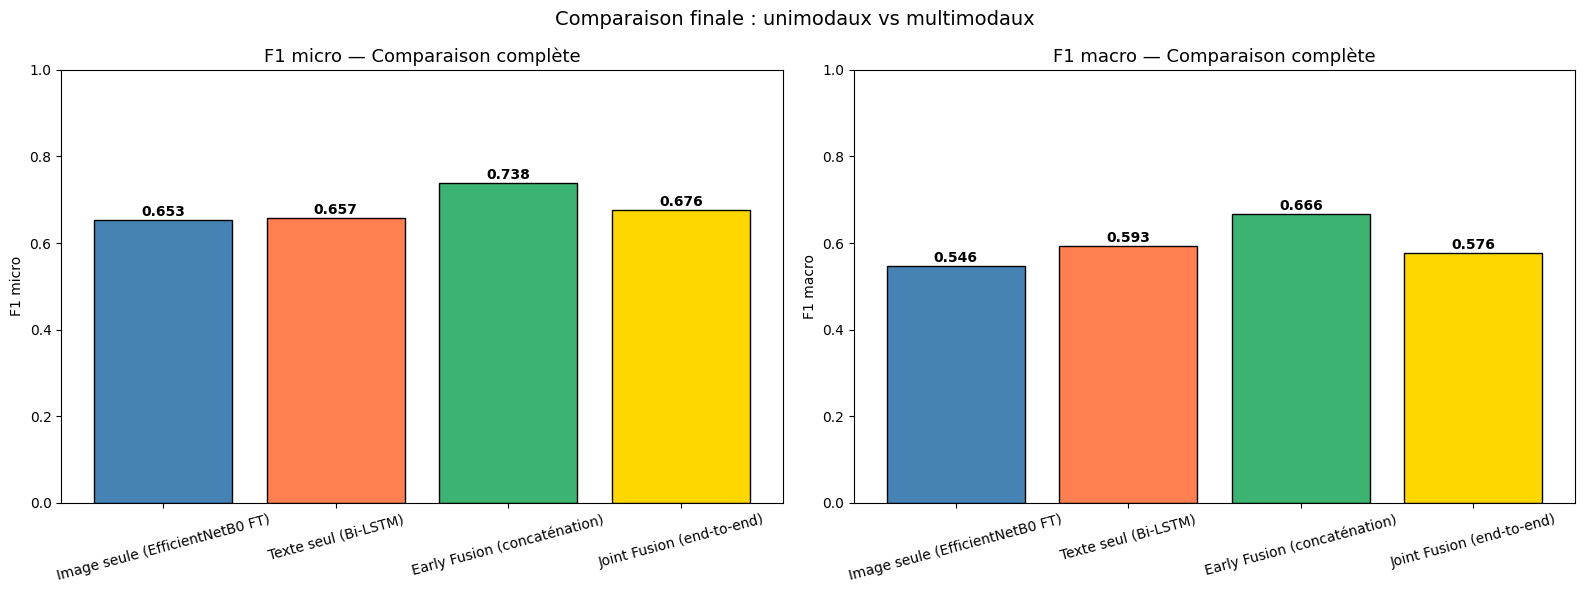

In [15]:
# ── Visualisation finale ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# F1 micro
colors = ['steelblue', 'coral', 'mediumseagreen', 'gold']
axes[0].bar(final_comparison['Modèle'], final_comparison['f1_micro'],
            color=colors, edgecolor='black')
axes[0].set_title('F1 micro — Comparaison complète', fontsize=13)
axes[0].set_ylabel('F1 micro')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(final_comparison['f1_micro']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

# F1 macro
axes[1].bar(final_comparison['Modèle'], final_comparison['f1_macro'],
            color=colors, edgecolor='black')
axes[1].set_title('F1 macro — Comparaison complète', fontsize=13)
axes[1].set_ylabel('F1 macro')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(final_comparison['f1_macro']):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Comparaison finale : unimodaux vs multimodaux', fontsize=14)
plt.tight_layout()
plt.savefig('../monitoring/output/fusion_final_comparison.png', bbox_inches='tight')
plt.show()

## 6. Analyse et interprétation

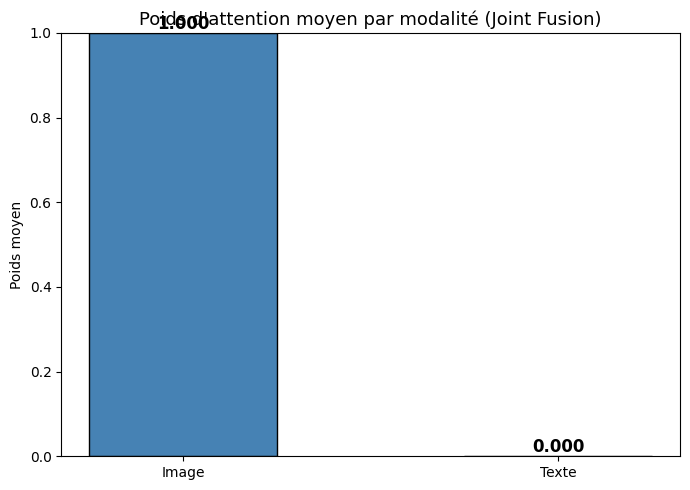

→ La modalité dominante est : image
  Image : 1.000 | Texte : 0.000


In [16]:
# ── Analyse des poids d'attention (Joint Fusion) ──────────────────────────────
# Visualiser la contribution moyenne de chaque modalité

joint_fusion.eval()
img_weights_all, text_weights_all = [], []

with torch.no_grad():
    for imgs, texts, labs in test_mm:
        imgs, texts = imgs.to(DEVICE), texts.to(DEVICE)
        # Extraire les poids d'attention
        img_feat  = joint_fusion.img_pool(joint_fusion.img_features(imgs)).flatten(1)
        img_proj  = joint_fusion.img_proj(img_feat)
        emb = joint_fusion.embedding(texts)
        out, _ = joint_fusion.lstm(emb)
        text_proj = joint_fusion.text_proj(out.mean(dim=1))
        concat  = torch.cat([img_proj, text_proj], dim=1)
        weights = joint_fusion.gate(concat).cpu().numpy()  # (B, 2)
        img_weights_all.append(weights[:, 0])
        text_weights_all.append(weights[:, 1])

img_w_mean  = np.concatenate(img_weights_all).mean()
text_w_mean = np.concatenate(text_weights_all).mean()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(['Image', 'Texte'], [img_w_mean, text_w_mean],
       color=['steelblue', 'coral'], edgecolor='black', width=0.5)
ax.set_title('Poids d\'attention moyen par modalité (Joint Fusion)', fontsize=13)
ax.set_ylabel('Poids moyen')
ax.set_ylim(0, 1)
for i, v in enumerate([img_w_mean, text_w_mean]):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../monitoring/output/fusion_attention_weights.png', bbox_inches='tight')
plt.show()

dominant = 'image' if img_w_mean > text_w_mean else 'texte'
print(f"→ La modalité dominante est : {dominant}")
print(f"  Image : {img_w_mean:.3f} | Texte : {text_w_mean:.3f}")

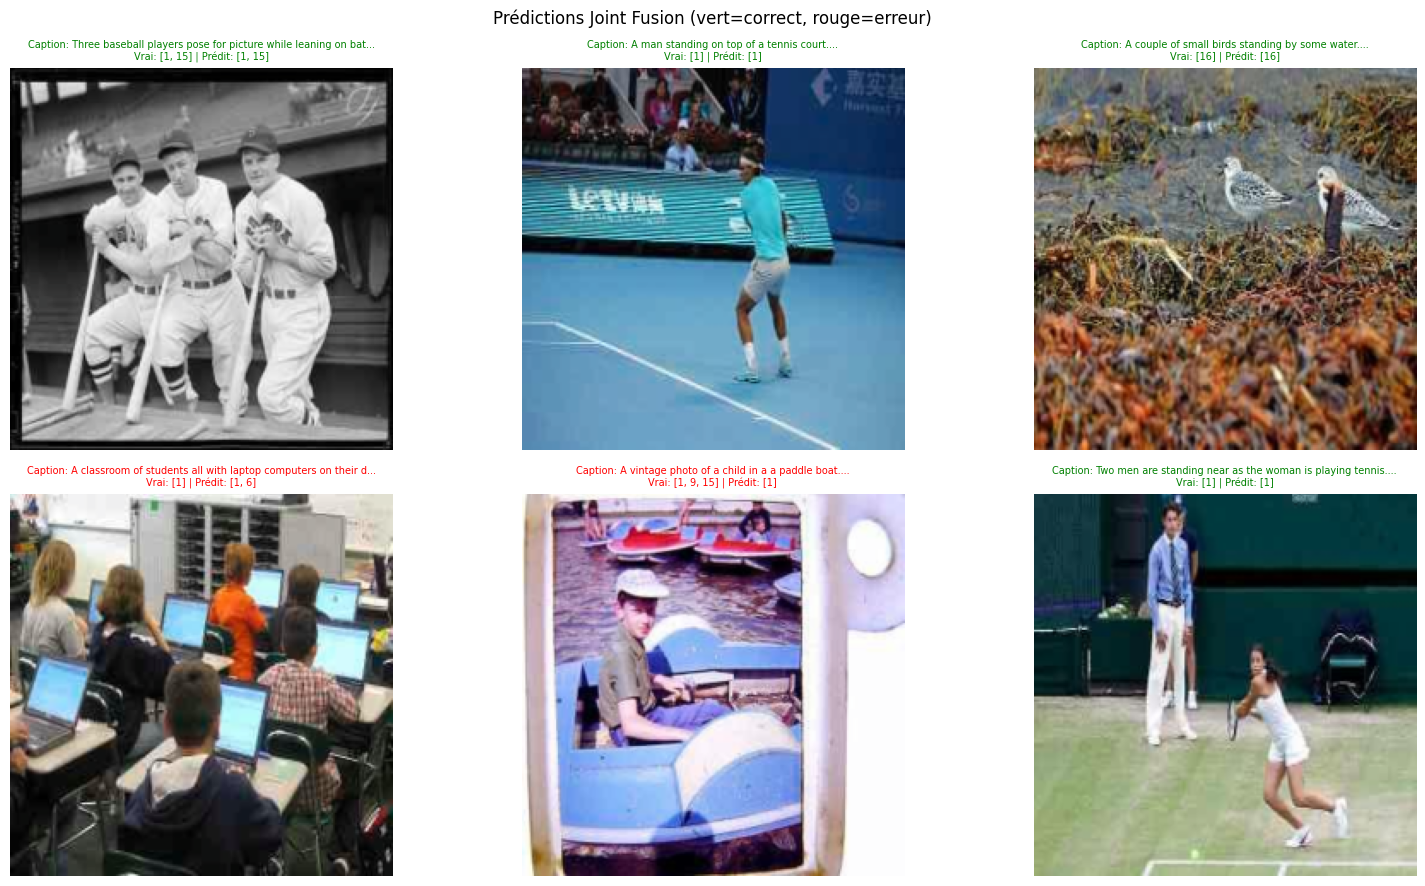

In [17]:
# ── Exemples de prédictions multimodales ──────────────────────────────────────
joint_fusion.eval()
sample_imgs, sample_texts, sample_labs = next(iter(test_mm))

with torch.no_grad():
    logits = joint_fusion(sample_imgs.to(DEVICE), sample_texts.to(DEVICE))
    probs  = torch.sigmoid(logits).cpu().numpy()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for i, ax in enumerate(axes.flatten()[:6]):
    img_np = sample_imgs[i].permute(1, 2, 0).numpy()
    img_np = (img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])).clip(0, 1)

    true_lab = [ALL_LABELS[j] for j in range(N_CLASSES) if sample_labs[i, j] == 1]
    pred_lab = [ALL_LABELS[j] for j in range(N_CLASSES) if probs[i, j] >= THRESHOLD]
    caption  = df_test['Caption'].iloc[i][:60]

    ax.imshow(img_np)
    ax.set_title(
        f"Caption: {caption}...\nVrai: {true_lab} | Prédit: {pred_lab}",
        fontsize=7, color='green' if set(true_lab) == set(pred_lab) else 'red'
    )
    ax.axis('off')

plt.suptitle('Prédictions Joint Fusion (vert=correct, rouge=erreur)', fontsize=12)
plt.tight_layout()
plt.savefig('../monitoring/output/fusion_predictions_examples.png', bbox_inches='tight')
plt.show()

## Synthèse et conclusions

### Résultats

| Modèle | F1 micro | F1 macro | Précision | Rappel | Gain vs image | Gain vs texte |
|--------|----------|----------|-----------|--------|---------------|---------------|
| Image seule (EfficientNetB0 FT) | 0.6531 | 0.5461 | 0.5476 | 0.8089 | — | — |
| Texte seul (Bi-LSTM) | 0.6575 | 0.5926 | 0.5741 | 0.7692 | — | — |
| **Early Fusion** | **0.7383** | **0.6665** | **0.6925** | **0.7907** | **+13.1%** | **+12.3%** |
| Joint Fusion (end-to-end) | 0.6761 | 0.5760 | 0.5863 | 0.7984 | +3.5% | +2.8% |

### Analyse comparative

**Contributions des modalités (Joint Fusion — poids d attention) :**
- La modalité **image est dominante** (poids d attention ≈ 1.000) dans le Joint Fusion
- Le texte contribue quasi nul (poids ≈ 0.000) — le modèle a appris à ignorer la modalité textuelle
- Cela explique pourquoi le Joint Fusion ne surpasse pas l Early Fusion

**Early Fusion vs Joint Fusion :**
- **Early Fusion remporte la comparaison** (F1 micro 0.7383 vs 0.6761)
- Early Fusion : extracteurs figés (EfficientNetB0 + Bi-LSTM) + MLP de fusion — les features ImageNet et NLP restent intactes
- Joint Fusion : entraînement end-to-end — le mécanisme d attention s est effondré sur la seule modalité image (attention collapse), n exploitant pas le texte

**Modèle retenu :** Early Fusion (meilleur F1 micro = 0.7383)

**Justification :** les extracteurs pré-entraînés fournissent des représentations robustes qu un simple MLP de fusion suffit à combiner efficacement. Le Joint Fusion souffre d un collapse d attention sur la modalité image, annulant l apport du texte. Gain multimodal de **+13.1 pts** vs image seule et **+12.3 pts** vs texte seul.

**Limites et pistes d amélioration :**
- Investiguons et corriger le collapse d attention dans le Joint Fusion (régularisation, gradient clipping)
- Utilisos BERT (texte) + ViT (image) pour des représentations pré-entraînées plus riches
- Implémentons un cross-attention transformer pour une interaction fine entre modalités
- Augmentons les données pour les classes rares (label 15, 2, 14 les plus difficiles)
- Optimisons les seuils de décision par classe via courbe ROC/PR